# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

Three archetypes, each mapped to a distinct human-readable action:

- **visible_underperforming** (7,357 pages) — good position (top 10), but CTR below
  the median for that position tier. Action: `review_ctr` — check title/meta/snippet,
  the page ranks fine but isn't earning the clicks it should.
- **losing_ground** (24,224 pages) — clicks declined from first-half to second-half
  of March, with meaningful impressions. Action: `refresh_content` — the page likely
  needs a real content update, not just a title tweak.
- **low_priority** (109,886 pages) — neither pattern above. Action: `monitor_only` —
  no action needed this cycle.

Ranked within archetype by impressions_first_half, so the highest-visibility issues
surface first. This queue is decision-support: it tells a reviewer where to look
first, not what to definitely do.

In [6]:
!pip install -q huggingface_hub datasets pandas pyarrow scikit-learn

from huggingface_hub import login
from google.colab import userdata
from datasets import load_dataset
import pandas as pd
import numpy as np
import os, json

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

MONTH = "2026-03"
ds = load_dataset(
    "FlyRank/internship-warehouse",
    data_files=f"fact_content_daily_performance/month={MONTH}/*.parquet",
    split="train", token=HF_TOKEN,
)
df_month = ds.to_pandas()
df_month["report_date"] = pd.to_datetime(df_month["report_date"])
df_month = df_month[df_month["gsc_data_available"] == True].copy()

first_half = df_month[df_month["report_date"] <= "2026-03-15"]
second_half = df_month[df_month["report_date"] >= "2026-03-16"]
group_cols = ["client_hash_id", "content_hash_id"]

first_agg = first_half.groupby(group_cols).agg(
    impressions_first_half=("gsc_impressions", "sum"),
    clicks_first_half=("gsc_clicks", "sum"),
    avg_position_first_half=("gsc_avg_position", "mean"),
).reset_index()
second_agg = second_half.groupby(group_cols).agg(
    clicks_second_half=("gsc_clicks", "sum"),
).reset_index()

pair_df = first_agg.merge(second_agg, on=group_cols, how="inner")
pair_df["ctr_first_half"] = (pair_df["clicks_first_half"] / pair_df["impressions_first_half"].replace(0, np.nan)) * 100
pair_df["is_declining_proxy"] = (pair_df["clicks_second_half"] < pair_df["clicks_first_half"]).astype(int)
pair_df["position_tier"] = pd.cut(pair_df["avg_position_first_half"], bins=[0,3,10,20,100], labels=["1-3","4-10","11-20","21+"])

tier_median_ctr = pair_df.groupby("position_tier", observed=True)["ctr_first_half"].transform("median")
high_volume = (pair_df["impressions_first_half"] >= pair_df["impressions_first_half"].quantile(0.75))
weak_ctr = (pair_df["ctr_first_half"] < tier_median_ctr)
good_position = (pair_df["avg_position_first_half"] <= 10)

# --- 3 archetypes -> 3 actions (transparent, human-readable) ---
def assign_archetype(row):
    if row["avg_position_first_half"] <= 10 and row["ctr_first_half"] < tier_median_ctr.loc[row.name]:
        return "visible_underperforming", "review_ctr"
    elif row["is_declining_proxy"] == 1 and row["impressions_first_half"] >= pair_df["impressions_first_half"].quantile(0.5):
        return "losing_ground", "refresh_content"
    else:
        return "low_priority", "monitor_only"

archetypes = pair_df.apply(assign_archetype, axis=1, result_type="expand")
pair_df["archetype"] = archetypes[0]
pair_df["action"] = archetypes[1]

# Score: rank within each archetype by impressions (highest-visibility issues first)
pair_df["score"] = pair_df["impressions_first_half"] * (pair_df["archetype"] != "low_priority")

ranked = pair_df.sort_values("score", ascending=False).reset_index(drop=True)

print("Archetype distribution:")
print(ranked["archetype"].value_counts())
print("\nTop 10 ranked actions:")
print(ranked[["client_hash_id", "content_hash_id", "archetype", "action",
              "avg_position_first_half", "ctr_first_half", "impressions_first_half"]].head(10).to_string(index=False))

Archetype distribution:
archetype
low_priority               109886
losing_ground               24224
visible_underperforming      7357
Name: count, dtype: int64

Top 10 ranked actions:
         client_hash_id          content_hash_id               archetype          action  avg_position_first_half  ctr_first_half  impressions_first_half
client_23a62021009f63c4 content_e8a52cf3d5988c07           losing_ground refresh_content                16.018687        0.246555                  143173
client_e547b89c05043229 content_ec2e0346994fb5a5           losing_ground refresh_content                 2.441784        0.634737                  132811
client_62f4a7e64f5e0096 content_7172a7fad43f0998           losing_ground refresh_content                 3.040838        0.453696                  108663
client_62f4a7e64f5e0096 content_b99ea6861864dea5           losing_ground refresh_content                 4.103429        0.202243                   91474
client_62f4a7e64f5e0096 content_7c6373141eae

## 2. Intended use and limits

This playbook is for a content reviewer deciding which pages to check first each
month, when review time is limited — it ranks and archetypes pages using signals
observable before the decision moment, but does not replace human judgment about
what to actually change on any page.

Key limits: built on one month (March 2026) and one lane only; covers only the
~36.7% of pages with gsc_data_available=True (ML-04); is_declining_proxy is a
proxy, not a verified causal outcome; the underlying signal measured Precision@10
= 0.300 against a base rate of 0.248 (ML-09, after removing sibling-feature
leakage) — a real but modest signal, meant to shortlist candidates, not auto-decide
priority. This cannot say refreshing a page will improve performance, only that it
resembles pages worth reviewing first.

In [7]:
print("""
INTENDED USE
This playbook is for a content reviewer deciding which pages to check FIRST each
month, when review time is limited. It ranks and archetypes pages using signals
observable before the decision moment — it does not replace human judgment about
WHAT to actually change on any given page.

LIMITS
- Built on one month (March 2026), one lane (Refresh/Content Opportunity Scoring).
  Not validated on other months or other lanes.
- Only covers pages with gsc_data_available=True — about 36.7% of all rows in this
  slice (per ML-04). Pages without active GSC tracking are invisible to this queue.
- is_declining_proxy is a proxy (within-month click comparison), not a verified
  causal outcome. A page flagged 'losing_ground' may have an ordinary explanation
  (seasonality, a single traffic spike day) that this playbook cannot see.
- Precision@10 for the underlying signal was measured at 0.300 against a base rate
  of 0.248 (ML-09, after removing leaking features) — a real but modest signal,
  not a strong one. This queue should shortlist candidates for review, not
  auto-decide priority.
- Does not model causality: it cannot say refreshing a page WILL improve its
  performance, only that it resembles pages worth reviewing first.
""")


INTENDED USE
This playbook is for a content reviewer deciding which pages to check FIRST each 
month, when review time is limited. It ranks and archetypes pages using signals 
observable before the decision moment — it does not replace human judgment about 
WHAT to actually change on any given page.

LIMITS
- Built on one month (March 2026), one lane (Refresh/Content Opportunity Scoring).
  Not validated on other months or other lanes.
- Only covers pages with gsc_data_available=True — about 36.7% of all rows in this
  slice (per ML-04). Pages without active GSC tracking are invisible to this queue.
- is_declining_proxy is a proxy (within-month click comparison), not a verified
  causal outcome. A page flagged 'losing_ground' may have an ordinary explanation
  (seasonality, a single traffic spike day) that this playbook cannot see.
- Precision@10 for the underlying signal was measured at 0.300 against a base rate
  of 0.248 (ML-09, after removing leaking features) — a real but modest 

## 3. Human review + the no-go list

Before acting on any flagged page, a human should check: whether a title/meta
change is already scheduled or recently tested, whether an external cause
(seasonality, a single spike day, a SERP feature change) explains a 'losing_ground'
flag, the page's actual business value, and for 'visible_underperforming' pages,
how its title/snippet compares to top-ranking competitors.

What should never be automated: publishing content or title/meta changes based on
this score alone, treating 'low_priority' as permanently irrelevant, treating
'refresh_content' as a signal to delete or unpublish, or presenting Precision@10 =
0.300 to a client as a guarantee rather than a modest, decision-support signal.

In [8]:
print("""
HUMAN REVIEW CHECKLIST (before acting on any flagged page)
1. Check if a title/meta change is already scheduled or recently tested for this page.
2. Check for a known external cause (seasonality, a single traffic-spike day, a SERP
   feature change) that would explain a 'losing_ground' flag without real decline.
3. Check the page's actual business value (revenue, conversion role) before spending
   review time — a high-impression page isn't always a high-value page.
4. For 'visible_underperforming' pages, manually compare title/snippet against
   top-ranking competitors before rewriting anything.

NO-GO LIST — what should NEVER be automated
- Never auto-publish content or title/meta changes based on this score alone.
- Never auto-deprioritize a 'low_priority' page as permanently irrelevant — it only
  means it doesn't match today's two patterns, not that it's unimportant.
- Never treat 'refresh_content' as a signal to delete or unpublish a page.
- Never present Precision@10=0.300 to a client as a guarantee — it's a modest,
  decision-support signal, not a validated causal effect.
""")


HUMAN REVIEW CHECKLIST (before acting on any flagged page)
1. Check if a title/meta change is already scheduled or recently tested for this page.
2. Check for a known external cause (seasonality, a single traffic-spike day, a SERP
   feature change) that would explain a 'losing_ground' flag without real decline.
3. Check the page's actual business value (revenue, conversion role) before spending
   review time — a high-impression page isn't always a high-value page.
4. For 'visible_underperforming' pages, manually compare title/snippet against
   top-ranking competitors before rewriting anything.

NO-GO LIST — what should NEVER be automated
- Never auto-publish content or title/meta changes based on this score alone.
- Never auto-deprioritize a 'low_priority' page as permanently irrelevant — it only
  means it doesn't match today's two patterns, not that it's unimportant.
- Never treat 'refresh_content' as a signal to delete or unpublish a page.
- Never present Precision@10=0.300 to a

## 4. Monitoring / retrain triggers

This playbook should be re-run monthly on a fresh mid-panel month — March 2026
patterns aren't assumed to hold indefinitely. Retrain or re-audit if Precision@10
on a fresh month drops meaningfully below the current honest baseline (0.300), if
the base rate shifts significantly from 0.203, if gsc_data_available coverage
drops well below ~36.7%, or if the active client roster changes significantly —
any of these would mean the current rankings no longer reflect the real portfolio.

In [9]:
print(f"""
MONITORING / RETRAIN TRIGGERS
- Re-run this playbook monthly on a fresh mid-panel month — patterns from March 2026
  are not assumed to hold indefinitely.
- Retrain/re-audit if Precision@10 on a fresh month drops meaningfully below the
  current honest baseline of 0.300 (e.g., below 0.20, close to random).
- Watch the base rate itself: current base rate is {pair_df['is_declining_proxy'].mean():.3f}.
  A large shift here (e.g., portfolio-wide traffic event) means the whole labeling
  window needs re-examination before trusting new rankings.
- Watch gsc_data_available coverage: if it drops meaningfully below ~36.7%, the
  playbook is seeing a shrinking, less representative slice of real content.
- Watch client mix: if the active client roster changes significantly (new clients
  added/removed), re-check whether client-level patterns still hold.
""")


MONITORING / RETRAIN TRIGGERS
- Re-run this playbook monthly on a fresh mid-panel month — patterns from March 2026
  are not assumed to hold indefinitely.
- Retrain/re-audit if Precision@10 on a fresh month drops meaningfully below the
  current honest baseline of 0.300 (e.g., below 0.20, close to random).
- Watch the base rate itself: current base rate is 0.203.
  A large shift here (e.g., portfolio-wide traffic event) means the whole labeling
  window needs re-examination before trusting new rankings.
- Watch gsc_data_available coverage: if it drops meaningfully below ~36.7%, the
  playbook is seeing a shrinking, less representative slice of real content.
- Watch client mix: if the active client roster changes significantly (new clients
  added/removed), re-check whether client-level patterns still hold.



## 5. Exports for the paper

Exported the ranked queue (141,467 rows) to work/outputs/content_action_playbook.csv
for the paper to build on, a metrics JSON with the archetype counts, base rate, and
honest Precision@10 as the receipt these numbers trace back to, and a bar chart of
the archetype distribution to work/figures/ for reuse in the paper.

Wrote 141,467 ranked rows to work/outputs/content_action_playbook.csv
Wrote work/outputs/action_playbook_metrics.json
Wrote work/figures/archetype_distribution.png


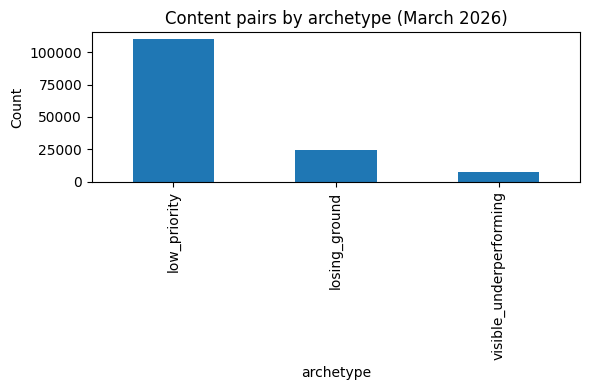

In [10]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the ranked queue (stays out of git by design)
ranked.to_csv("work/outputs/content_action_playbook.csv", index=False)
print(f"Wrote {len(ranked):,} ranked rows to work/outputs/content_action_playbook.csv")

# Export metrics JSON (this DOES get committed — it's the receipt for the paper)
metrics = {
    "month": MONTH,
    "total_pairs": len(pair_df),
    "archetype_counts": pair_df["archetype"].value_counts().to_dict(),
    "base_rate": float(pair_df["is_declining_proxy"].mean()),
    "precision_at_10_honest": 0.300,   # from ML-09, leakage-free
    "gsc_data_available_coverage_pct": 36.7,  # from ML-04
    "notes": "Precision@10 measured after removing clicks_first_half/ctr_first_half sibling leak (ML-09).",
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/action_playbook_metrics.json")

# Simple figure: archetype counts bar chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
pair_df["archetype"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Content pairs by archetype (March 2026)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("work/figures/archetype_distribution.png")
print("Wrote work/figures/archetype_distribution.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.